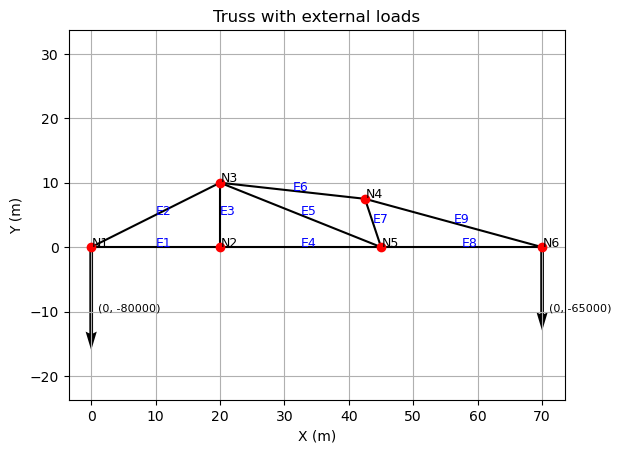

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Materiaal
E = 210e9  # Pa

# Knooppunten (id: (x, y))
nodes = {
    1: (0.0, 0.0),
    2: (20, 0.0),
    3: (20.0, 10.0),
    4: (42.5, 7.5),
    5: (45, 0),
    6: (70,0),
}

# Elementen (id: node1, node2, area in m^2)
elements = {
    1: {"n1": 1, "n2": 2, "A": 0.05},
    2: {"n1": 1, "n2": 3, "A": 0.005},
    3: {"n1": 2, "n2": 3, "A": 0.06},
    4: {"n1": 2, "n2": 5, "A": 0.03},
    5: {"n1": 3, "n2": 5, "A": 0.005},
    6: {"n1": 3, "n2": 4, "A": 0.005},
    7: {"n1": 5, "n2": 4, "A": 0.02},
    8: {"n1": 5, "n2": 6, "A": 0.02},
    9: {"n1": 4, "n2": 6, "A": 0.005},
}

# Belastingen (node: (Fx, Fy) in [N])
loads = {
    1: (0.0, -80000.0),
    6: (0.0, -65000.0),
}

# Opleggingen (node: (fix_x, fix_y))
fixed_dofs = {
    2: (True, True),   # scharnier
    3: (True, False),  # rol
}

import matplotlib.pyplot as plt

# staven tekenen
for eid, elem in elements.items():
    n1 = elem["n1"]
    n2 = elem["n2"]

    x1, y1 = nodes[n1]
    x2, y2 = nodes[n2]

    plt.plot([x1, x2], [y1, y2], 'k-')

    xm = (x1 + x2) / 2
    ym = (y1 + y2) / 2
    plt.text(xm, ym, f'E{eid}', color='blue', fontsize=9)

# nodes tekenen
for node_id, (x, y) in nodes.items():
    plt.plot(x, y, 'ro')
    plt.text(x + 0.1, y + 0.1, f'N{node_id}', fontsize=9)

# externe belastingen tekenen
scale = 5000  # schaalfactor voor zichtbare pijlen

for node_id, (Fx, Fy) in loads.items():
    x, y = nodes[node_id]

    plt.quiver(
        x, y,                 # startpunt
        Fx / scale, Fy / scale,  # pijlvector geschaald
        angles='xy',
        scale_units='xy',
        scale=1,
    )

    plt.text(x + 1, y - 10, f'({Fx:.0f}, {Fy:.0f})', fontsize=8)

plt.axis('equal')
plt.title("Truss with external loads")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid()
plt.show()

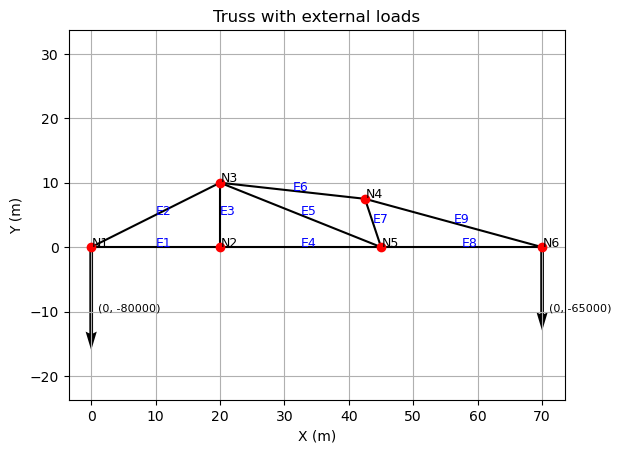

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Materiaal
E = 210e9  # Pa

# Knooppunten (id: (x, y))
nodes = {
    1: (0.0, 0.0),
    2: (20, 0.0),
    3: (20.0, 10.0),
    4: (42.5, 7.5),
    5: (45, 0),
    6: (70,0),
}

# Elementen (id: node1, node2, area in m^2)
elements = {
    1: {"n1": 1, "n2": 2, "A": 0.05},
    2: {"n1": 1, "n2": 3, "A": 0.005},
    3: {"n1": 2, "n2": 3, "A": 0.06},
    4: {"n1": 2, "n2": 5, "A": 0.03},
    5: {"n1": 3, "n2": 5, "A": 0.005},
    6: {"n1": 3, "n2": 4, "A": 0.005},
    7: {"n1": 5, "n2": 4, "A": 0.02},
    8: {"n1": 5, "n2": 6, "A": 0.02},
    9: {"n1": 4, "n2": 6, "A": 0.005},
}

# Belastingen (node: (Fx, Fy) in [N])
loads = {
    1: (0.0, -80000.0),
    6: (0.0, -65000.0),
}

# Opleggingen (node: (fix_x, fix_y))
fixed_dofs = {
    2: (True, True),   # scharnier
    3: (True, False),  # rol
}

import matplotlib.pyplot as plt

# staven tekenen
for eid, elem in elements.items():
    n1 = elem["n1"]
    n2 = elem["n2"]

    x1, y1 = nodes[n1]
    x2, y2 = nodes[n2]

    plt.plot([x1, x2], [y1, y2], 'k-')

    xm = (x1 + x2) / 2
    ym = (y1 + y2) / 2
    plt.text(xm, ym, f'E{eid}', color='blue', fontsize=9)

# nodes tekenen
for node_id, (x, y) in nodes.items():
    plt.plot(x, y, 'ro')
    plt.text(x + 0.1, y + 0.1, f'N{node_id}', fontsize=9)

# externe belastingen tekenen
scale = 5000  # schaalfactor voor zichtbare pijlen

for node_id, (Fx, Fy) in loads.items():
    x, y = nodes[node_id]

    plt.quiver(
        x, y,                 # startpunt
        Fx / scale, Fy / scale,  # pijlvector geschaald
        angles='xy',
        scale_units='xy',
        scale=1,
    )

    plt.text(x + 1, y - 10, f'({Fx:.0f}, {Fy:.0f})', fontsize=8)

plt.axis('equal')
plt.title("Truss with external loads")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid()
plt.show()

In [5]:
# Analyse 1-staaf element

elem = elements[2]
n1 = elem["n1"]
n2 = elem["n2"]

x1, y1 = nodes[n1]
x2, y2 = nodes[n2]

from solver import element_stiffness

ke, L, c, s = element_stiffness(x1, y1, x2, y2, E, elem["A"])

print("Length:", L)
print("cos:", c)
print("sin:", s)
print("ke:\n", ke)

Length: 22.360679774997898
cos: 0.8944271909999159
sin: 0.4472135954999579
ke:
 [[ 37565942.02199646  18782971.01099823 -37565942.02199646
  -18782971.01099823]
 [ 18782971.01099823   9391485.50549912 -18782971.01099823
   -9391485.50549912]
 [-37565942.02199646 -18782971.01099823  37565942.02199646
   18782971.01099823]
 [-18782971.01099823  -9391485.50549912  18782971.01099823
    9391485.50549912]]
